# **Business Case Study**
Jamboree Education - Linear Regression

# **Submitted By: Heena Khan**


**Context**
Jamboree has helped thousands of students like you make it to top colleges abroad. Be it GMAT, GRE or SAT, their unique problem-solving methods ensure maximum scores with minimum effort.

They recently launched a feature where students/learners can come to their website and check their probability of getting into the IVY league college. This feature estimates the chances of graduate admission from an Indian perspective.

How can you help here?

Your analysis will help Jamboree in understanding what factors are important in graduate admissions and how these factors are interrelated among themselves. It will also help predict one's chances of admission given the rest of the variables.


Problem Statement :
Jamboree wants to help students estimate their probability of admission to graduate programs.


Dataset
Dataset Link: jamboree_admission.csv


•	Serial No.: This column represents the unique row identifier for each applicant in the dataset.

•	GRE Scores: This column contains the GRE (Graduate Record Examination) scores of the applicants, which are measured on a scale of 0 to 340.

•	TOEFL Scores: This column includes the TOEFL (Test of English as a Foreign Language) scores of the applicants, which are measured on a scale of 0 to 120.

•	University Rating: This column indicates the rating or reputation of the university that the applicants are associated with.

	The rating is based on a scale of 0 to 5, with 5 representing the highest rating.

•	SOP: This column represents the strength of the applicant's statement of purpose, rated on a scale of 0 to 5, with 5 indicating a strong and compelling SOP.

•	LOR: This column represents the strength of the applicant's letter of recommendation, rated on a scale of 0 to 5, with 5 indicating a strong and compelling LOR.

•	CGPA: This column contains the undergraduate Grade Point Average (GPA) of the applicants, which is measured on a scale of 0 to 10.

•	Research: This column indicates whether the applicant has research experience (1) or not (0).

•	Chance of Admit: This column represents the estimated probability or chance of admission for each applicant, ranging from 0 to 1.


**Column Profiling:**

•	Serial No. (Unique row ID)

•	GRE Scores (out of 340)

•	TOEFL Scores (out of 120)

•	University Rating (out of 5)

•	Statement of Purpose and Letter of Recommendation Strength (out of 5)

•	Undergraduate GPA (out of 10)

•	Research Experience (either 0 or 1)

•	Chance of Admit (ranging from 0 to 1)


**Concept Used:**

•	Exploratory Data Analysis

•	Linear Regression

What does good looks like?

•	Import the dataset and do usual exploratory data analysis steps like checking the structure & characteristics of the dataset.

•	Drop the unique row Identifier if you see any. This step is important as you don’t want your model to build some understanding based on row numbers.

•	Use Non-graphical and graphical analysis for getting inferences about variables.

o	This can be done by checking the distribution of variables of graduate applicants.

•	Once you’ve ensured that students with varied merit apply for the university, you can start understanding the relationship between different factors responsible for graduate admissions.

•	Check correlation among independent variables and how they interact with each other.

•	Use Linear Regression from (Statsmodel library) and explain the results.

•	Test the assumptions of linear regression:

o	Multicollinearity check by VIF score

o	Mean of residuals

o	Linearity of variables (no pattern in residual plot)

o	Test for Homoscedasticity

o	Normality of residuals

•	Do model evaluation- MAE, RMSE, R2 score, Adjusted R2.

•	Provide actionable Insights & Recommendations

•	Try out different Linear Regressions


# **Descriptive/Diagnostic**

Which factors are important in determining the Chance of Admit?

For example:

•	Does GRE score matter?

•	Does TOEFL score matter?

•	Does CGPA matter?

•	Does research experience matter?

•	Are GRE and TOEFL highly related to each other?


# **Predictive**

Given a student's:

•	GRE

•	TOEFL

•	University Rating

•	SOP/LOR

•	CGPA

•	Research Experience

can we predict their Chance of Admit?

# **This is a regression problem because our target variable is numerical.**



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/sample_data/Jamboree_Admission.csv")

df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
df.shape

(500, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [ ]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [ ]:
df.isnull().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


In [ ]:
df.isna().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


In [ ]:
df.isna().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


In [ ]:
df.nunique()

,0
Serial No.,500
GRE Score,49
TOEFL Score,29
University Rating,5
SOP,9
LOR,9
CGPA,184
Research,2
Chance of Admit,61


Drop Serial Number

In [ ]:
df = df.drop("Serial No.", axis=1)

Rename Columns

In [ ]:
df.columns = [
    "GRE",
    "TOEFL",
    "University_Rating",
    "SOP",
    "LOR",
    "CGPA",
    "Research",
    "Chance_of_Admit"
]

df.head()

,GRE,TOEFL,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


Check Data Types :
All variables should essentially be numerical.

This is convenient because Linear Regression requires numerical predictors.

In [ ]:
df.dtypes

,0
GRE,int64
TOEFL,int64
University_Rating,int64
SOP,float64
LOR,float64
CGPA,float64
Research,int64
Chance_of_Admit,float64


Univariate Analysis : Understand the distribution of individual variables.

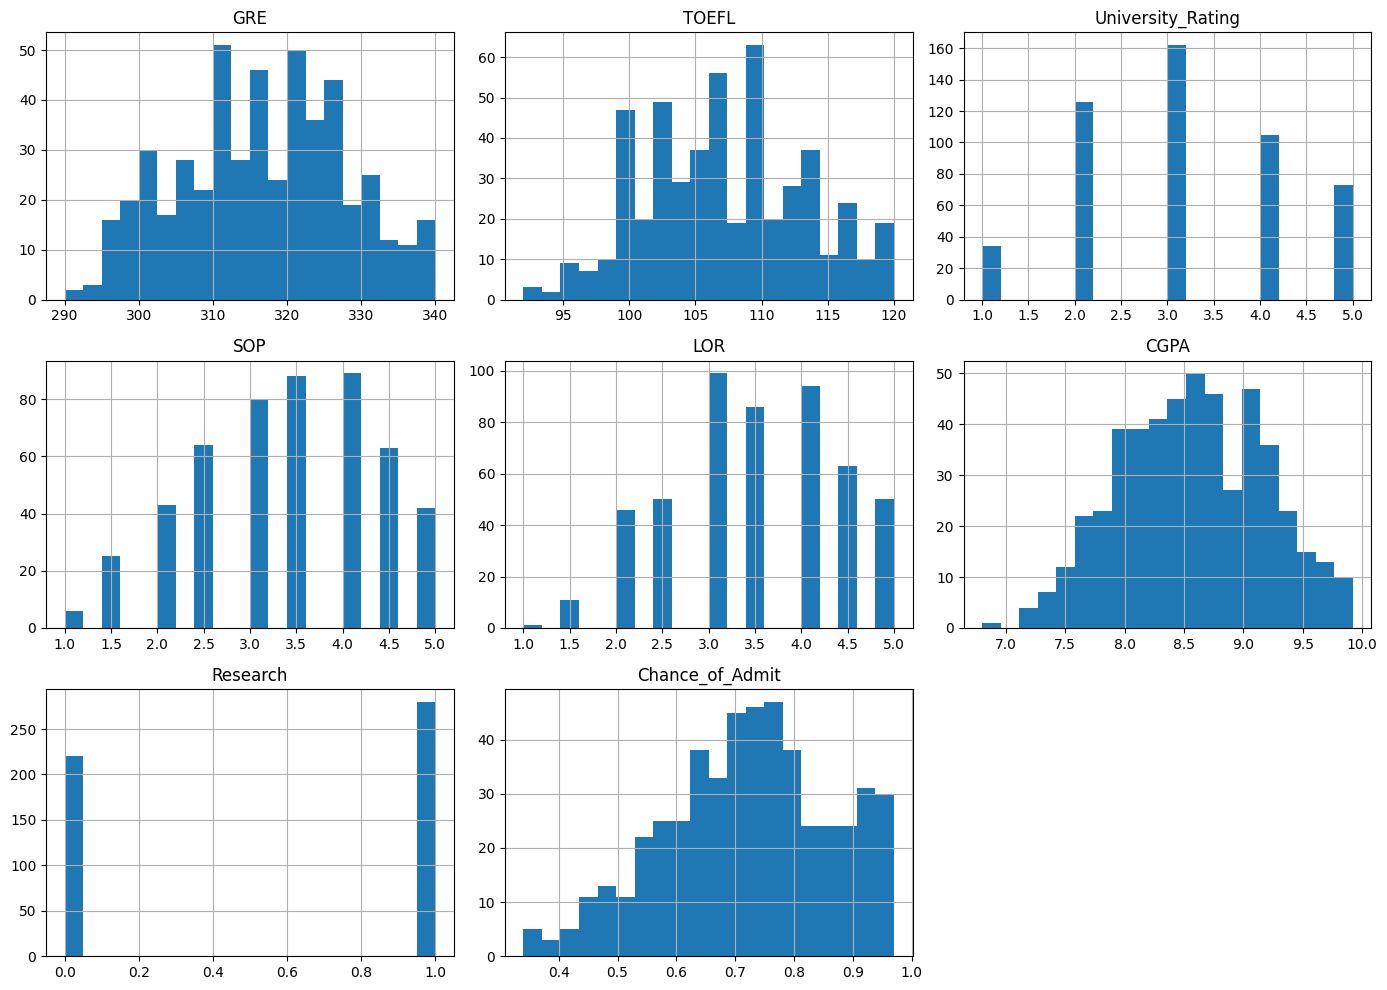

In [ ]:
df.hist(figsize=(14,10), bins=20)

plt.tight_layout()
plt.show()

Distribution of GRE

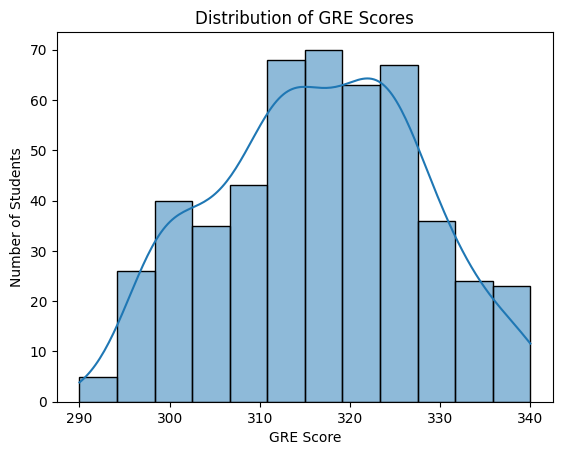

In [ ]:
sns.histplot(df["GRE"], kde=True)

plt.title("Distribution of GRE Scores")
plt.xlabel("GRE Score")
plt.ylabel("Number of Students")
plt.show()

Interpretation

We can determine whether GRE scores are:

approximately normally distributed
skewed
concentrated around a particular range

Distribution of TOEFL

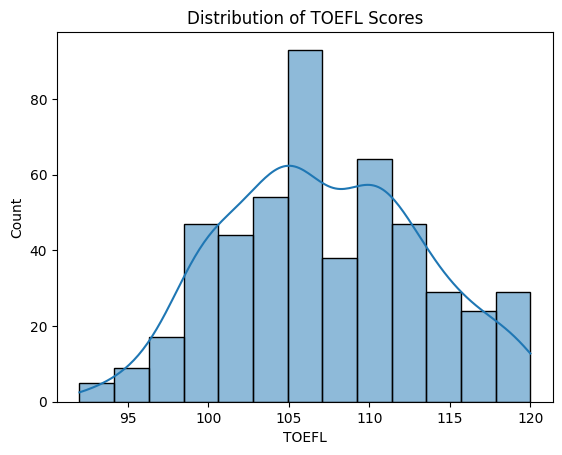

In [ ]:
sns.histplot(df["TOEFL"], kde=True)

plt.title("Distribution of TOEFL Scores")
plt.show()

Distribution of CGPA

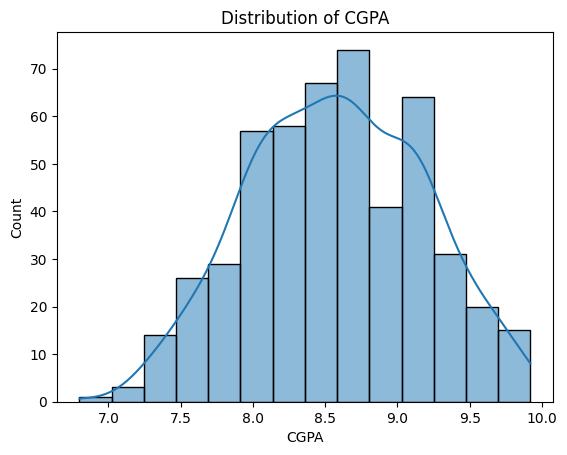

In [ ]:
sns.histplot(df["CGPA"], kde=True)

plt.title("Distribution of CGPA")
plt.show()

CGPA is particularly important because academic performance is expected to influence graduate admission chances.

Boxplots

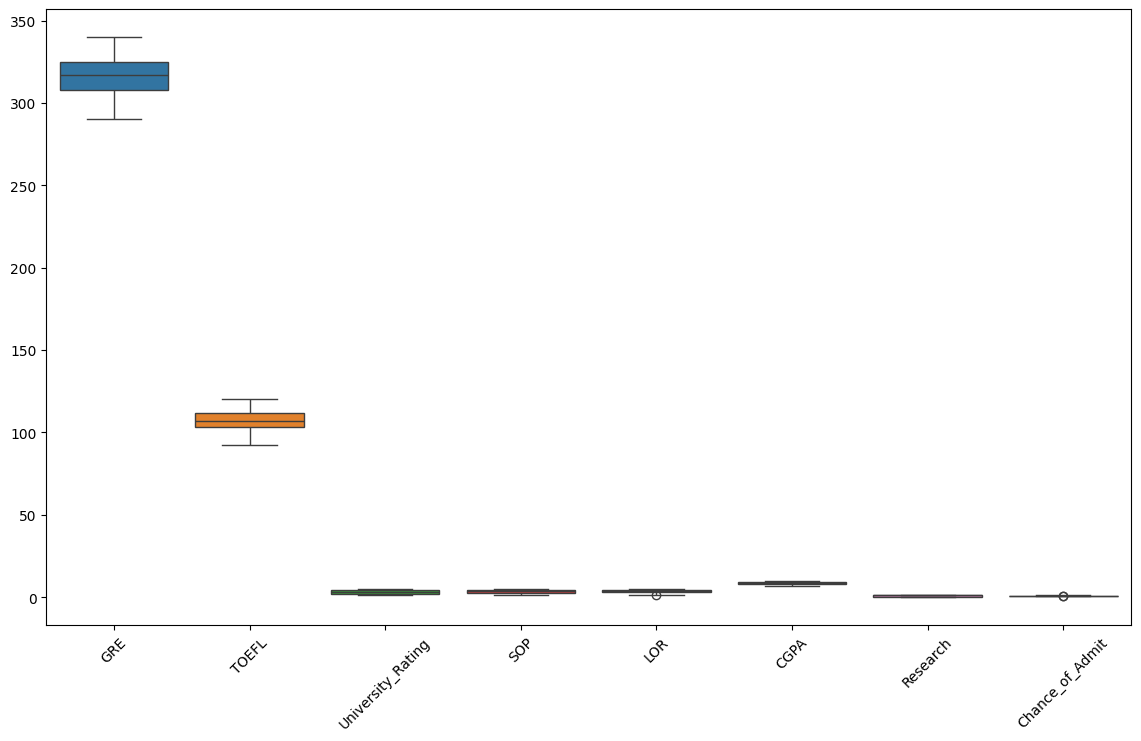

In [ ]:
plt.figure(figsize=(14,8))

sns.boxplot(data=df)

plt.xticks(rotation=45)
plt.show()

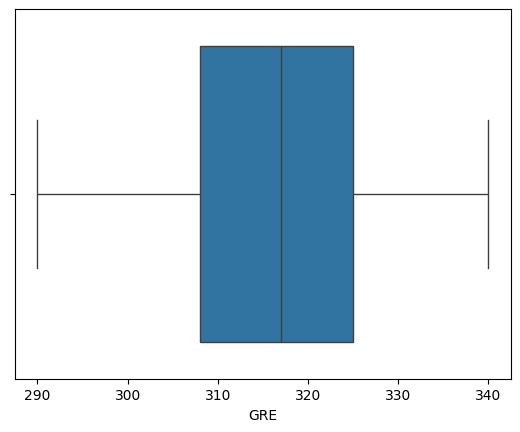

In [ ]:
sns.boxplot(x=df["GRE"])
plt.show()

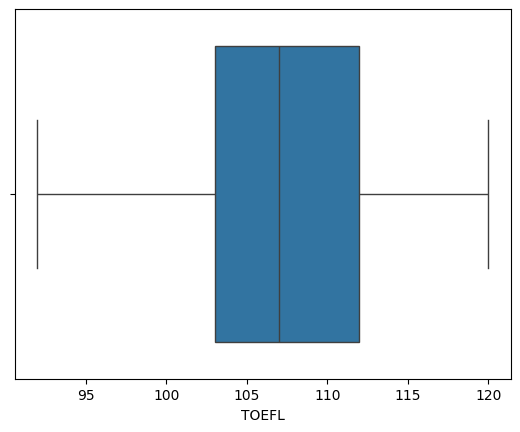

In [ ]:
sns.boxplot(x=df["TOEFL"])
plt.show()

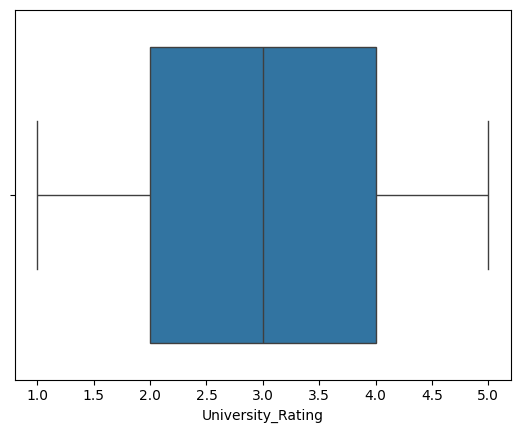

In [ ]:
sns.boxplot(x=df["University_Rating"])
plt.show()

Categorical/Discrete Variables

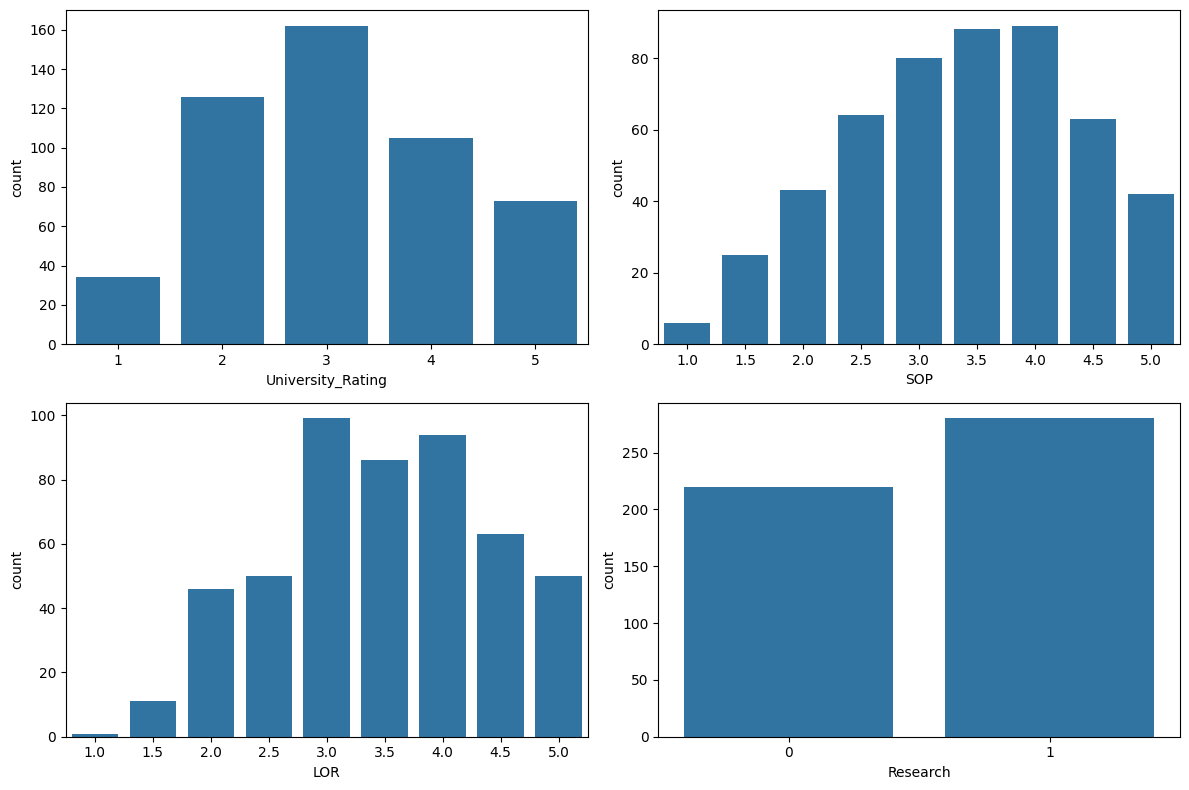

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

sns.countplot(x="University_Rating", data=df, ax=axes[0,0])
sns.countplot(x="SOP", data=df, ax=axes[0,1])
sns.countplot(x="LOR", data=df, ax=axes[1,0])
sns.countplot(x="Research", data=df, ax=axes[1,1])

plt.tight_layout()
plt.show()

Research Experience

In [ ]:
df["Research"].value_counts()

,count
Research,
1,280
0,220


Calculate percentages: This tells us what percentage of applicants have research experience.

In [ ]:
df["Research"].value_counts(normalize=True) * 100

,proportion
Research,
1,56.0
0,44.0


Target Variable Distribution: target is: Chance_of_Admit
We want to understand whether admission chances are:  

evenly distributed,
concentrated around high probabilities or
skewed

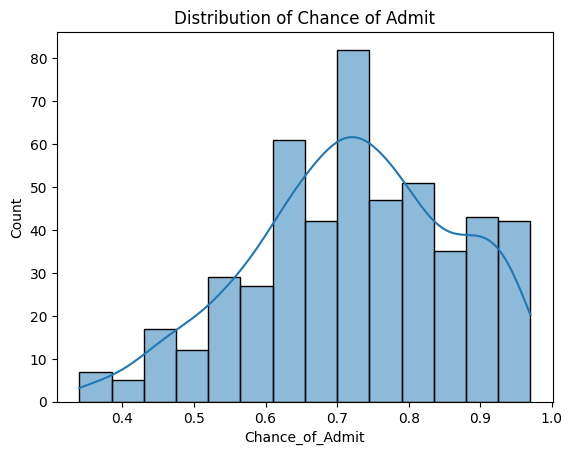

In [ ]:
sns.histplot(df["Chance_of_Admit"], kde=True)

plt.title("Distribution of Chance of Admit")
plt.show()

Bivariate analysis: Relationship Between GRE and Chance of Admit

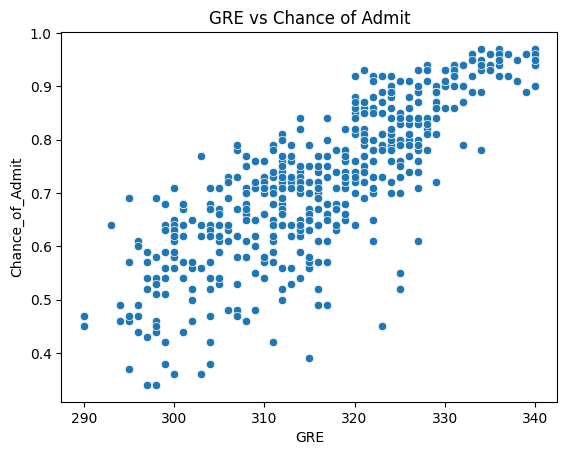

In [ ]:
sns.scatterplot(data=df, x="GRE", y="Chance_of_Admit")

plt.title("GRE vs Chance of Admit")
plt.show()

As GRE increases, Chance of Admit generally increases.

GRE vs Chance of Admit with Regression Line.  The regression line gives us the general trend.

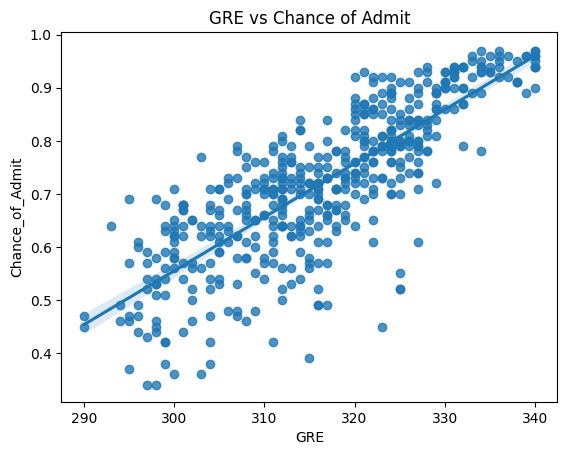

In [ ]:
sns.regplot(data=df, x="GRE", y="Chance_of_Admit")

plt.title("GRE vs Chance of Admit")
plt.show()

TOEFL vs Chance of Admit

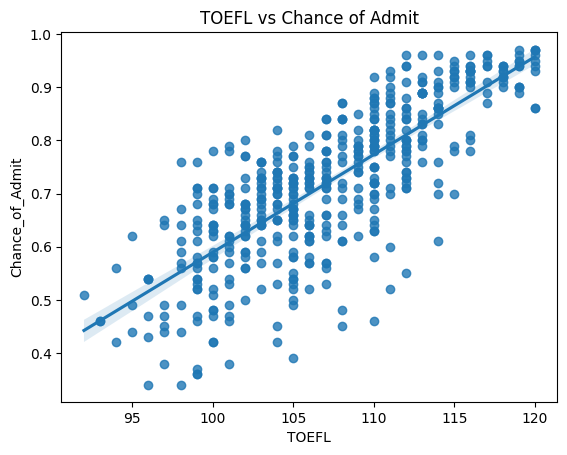

In [ ]:
sns.regplot(data=df, x="TOEFL", y="Chance_of_Admit")

plt.title("TOEFL vs Chance of Admit")
plt.show()

Higher TOEFL scores tend to be associated with higher admission chances.

CGPA vs Chance of Admit

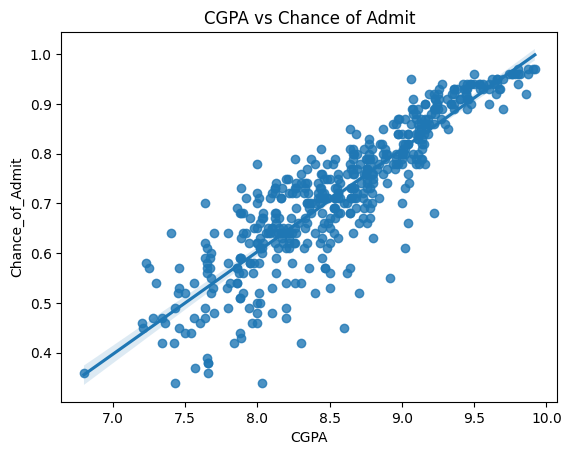

In [ ]:
sns.regplot(data=df, x="CGPA", y="Chance_of_Admit")

plt.title("CGPA vs Chance of Admit")
plt.show()

This relationship is strong and positive.

Research vs Chance of Admit

Since Research is binary:

0 = No research
1 = Research

So Use boxplot.

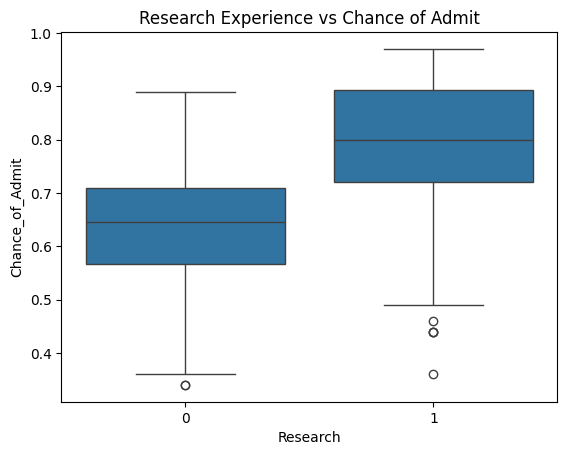

In [ ]:
sns.boxplot(data=df, x="Research", y="Chance_of_Admit")

plt.title("Research Experience vs Chance of Admit")
plt.show()

Students with research experience tend to have higher admission chances.

Correlation Matrix : Understand how variables interact with one another.

In [ ]:
corr = df.corr()

corr

,GRE,TOEFL,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admit
GRE,1.000000,0.827200,0.635376,0.613498,0.524679,0.825878,0.563398,0.810351
TOEFL,0.827200,1.000000,0.649799,0.644410,0.541563,0.810574,0.467012,0.792228
University_Rating,0.635376,0.649799,1.000000,0.728024,0.608651,0.705254,0.427047,0.690132
SOP,0.613498,0.644410,0.728024,1.000000,0.663707,0.712154,0.408116,0.684137
LOR,0.524679,0.541563,0.608651,0.663707,1.000000,0.637469,0.372526,0.645365
CGPA,0.825878,0.810574,0.705254,0.712154,0.637469,1.000000,0.501311,0.882413
Research,0.563398,0.467012,0.427047,0.408116,0.372526,0.501311,1.000000,0.545871
Chance_of_Admit,0.810351,0.792228,0.690132,0.684137,0.645365,0.882413,0.545871,1.000000


Correlation Heatmap

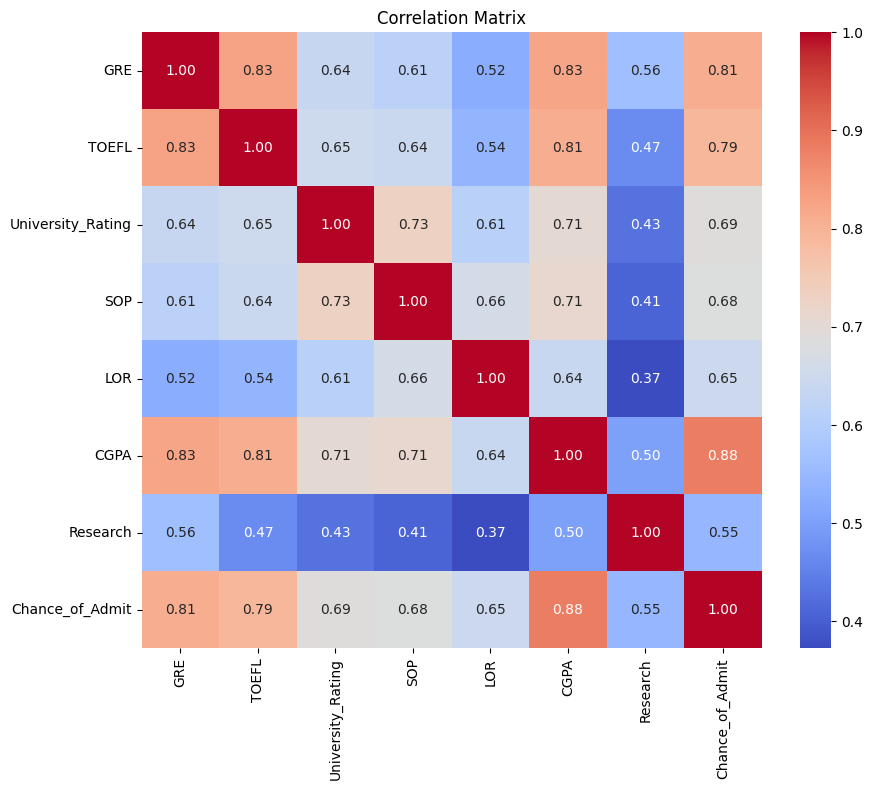

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

Variables such as:
GRE
TOEFL
CGPA
have relatively strong positive correlations with: Chance_of_Admit
GRE ↔ TOEFL
GRE ↔ CGPA
TOEFL ↔ CGPA
are themselves highly correlated.

Separate X and y

In [ ]:
X = df.drop("Chance_of_Admit", axis=1)

y = df["Chance_of_Admit"]

X = GRE, TOEFL, University Rating, SOP, LOR, CGPA, Research

y = Chance of Admit

Train-Test Split

We should not train and evaluate the model on the exact same data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

We now have:

80% → training
20% → testing

Approximately:

400 training observations
100 testing observations

Statsmodels Linear Regression : Statsmodels requires us to explicitly add an intercept.

In [ ]:
X_train_sm = sm.add_constant(X_train)

model = sm.OLS(y_train, X_train_sm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Chance_of_Admit   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     257.0
Date:                Fri, 14 Aug 2026   Prob (F-statistic):          3.41e-142
Time:                        05:20:34   Log-Likelihood:                 561.91
No. Observations:                 400   AIC:                            -1108.
Df Residuals:                     392   BIC:                            -1076.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.4214      0.12

R-squared  :  0.821   
Interpretation:

Approximately 82% of the variation in Chance of Admit is explained by the predictors included in the model.

Adjusted R-squared :  0.818    
Adjusted R² also measures explanatory power but penalizes unnecessary predictors.
Interpretation:
The values being close suggests that the predictors are collectively useful and that we haven't gained R² simply by adding many unnecessary variables.

Coefficient :
GRE  :  0.0024
It means:
Holding all other variables constant, a 1-point increase in GRE is associated with approximately a 0.0024 increase in predicted Chance of Admit.
For example:

GRE increases by 10 points

Change in predicted chance
= 10 × 0.0024
= 0.024

So predicted admission probability increases by approximately:

0.02 = 2.4 percentage points

P-value

The P>|t| column tells us whether a predictor is statistically significant.

Common rule:

p-value < 0.05 → statistically significant
p-value > 0.05 → not statistically significant

GRE                         0.000             
TOEFL                       0.002              
University_Rating           0.541           
SOP                         0.721           
LOR                         0.000             
CGPA                        0.000             
Research                    0.001   
Interpretation:
University_Rating           0.541   > 0.05    not statistically significant    
SOP                         0.721   > 0.05    not statistically significan

Confidence Interval :
Statsmodels gives:  [0.025    0.975]

This represents the approximate 95% confidence interval for the coefficient.

For example:

GRE coefficient = 0.002
95% CI = [0.001, 0.003]

Since the interval does not contain zero, it supports statistical significance.

Extract Coefficients

In [ ]:
model.params

,0
const,-1.421447
GRE,0.002434
TOEFL,0.002996
University_Rating,0.002569
SOP,0.001814
LOR,0.017238
CGPA,0.112527
Research,0.024027


In [ ]:
model.pvalues

,0
const,9.326216e-27
GRE,3.357625e-05
TOEFL,1.619658e-03
University_Rating,5.414408e-01
SOP,7.211636e-01
LOR,1.947965e-04
CGPA,1.086636e-22
Research,1.337508e-03


In [ ]:
model.conf_int()

,0,1
const,-1.663419,-1.179475
GRE,0.001294,0.003575
TOEFL,0.001140,0.004851
University_Rating,-0.005695,0.010832
SOP,-0.008170,0.011797
LOR,0.008228,0.026248
CGPA,0.091344,0.133710
Research,0.009407,0.038647


Create a useful table:

In [ ]:
results = pd.DataFrame({
    "Coefficient": model.params,
    "P_value": model.pvalues,
    "Significant": model.pvalues < 0.05
})

results

,Coefficient,P_value,Significant
const,-1.421447,9.326216e-27,True
GRE,0.002434,3.357625e-05,True
TOEFL,0.002996,1.619658e-03,True
University_Rating,0.002569,5.414408e-01,False
SOP,0.001814,7.211636e-01,False
LOR,0.017238,1.947965e-04,True
CGPA,0.112527,1.086636e-22,True
Research,0.024027,1.337508e-03,True


Calculate VIF :
Multicollinearity — VIF (Variance Inflation Factor)

Now we test the first major assumption.
It tells us how strongly a predictor is explained by the other predictors.

In [ ]:
X_vif = sm.add_constant(X)

vif = pd.DataFrame()

vif["Feature"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif

,Feature,VIF
0,const,1511.495830
1,GRE,4.464249
2,TOEFL,3.904213
3,University_Rating,2.621036
4,SOP,2.835210
5,LOR,2.033555
6,CGPA,4.777992
7,Research,1.494008


Mean of Residuals : A fundamental property of OLS with an intercept is that the residuals sum to approximately zero.

In [ ]:
residuals = model.resid

print("Mean residual:", residuals.mean())

Mean residual: 3.920475055707584e-16


Linearity Assumption :
Linear regression assumes:

The relationship between predictors and target is approximately linear.

We can investigate this using residual plots.

First generate predictions:

In [ ]:
y_train_pred = model.predict(X_train_sm)

calculate residuals

In [ ]:
residuals = y_train - y_train_pred

Plot

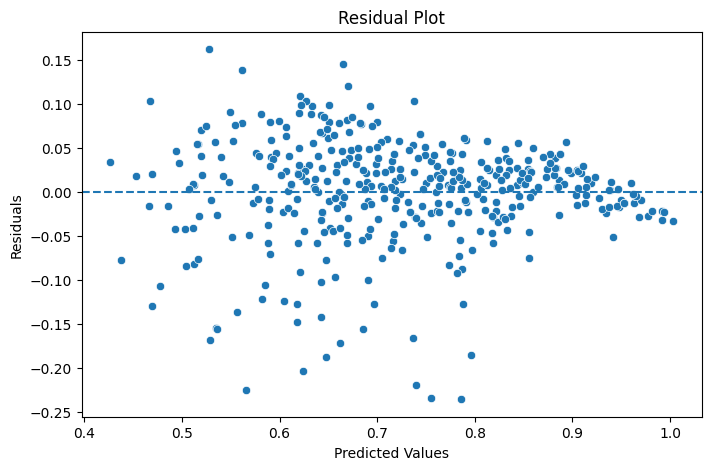

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=y_train_pred,
    y=residuals
)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

Homoscedasticity:
Residual variance to remain approximately constant across predicted values.

Breusch-Pagan Test

In [ ]:
bp_test = het_breuschpagan(
    residuals,
    model.model.exog
)

labels = [
    "LM Statistic",
    "LM-Test p-value",
    "F-Statistic",
    "F-Test p-value"
]

dict(zip(labels, bp_test))

{'LM Statistic': np.float64(25.155865692455404),
 'LM-Test p-value': np.float64(0.0007119983594307657),
 'F-Statistic': np.float64(3.7581713300112587),
 'F-Test p-value': np.float64(0.0005879783560629873)}

Null hypothesis
H0 :Residuals are homoscedastic

If:  p-value > 0.05

We fail to reject H₀.

Therefore:

No statistically significant evidence of heteroscedasticity.

If:
p-value < 0.05

There is evidence of heteroscedasticity.

Here, p-value: 0.000712
Therefore, There is statistically significant evidence of heteroscedasticity in the residuals.

Normality of Residuals:
OLS does not require residuals to be perfectly normal for coefficient estimation, but normality is useful for reliable small-sample inference and is commonly checked as part of regression diagnostics.So we First create a histogram.

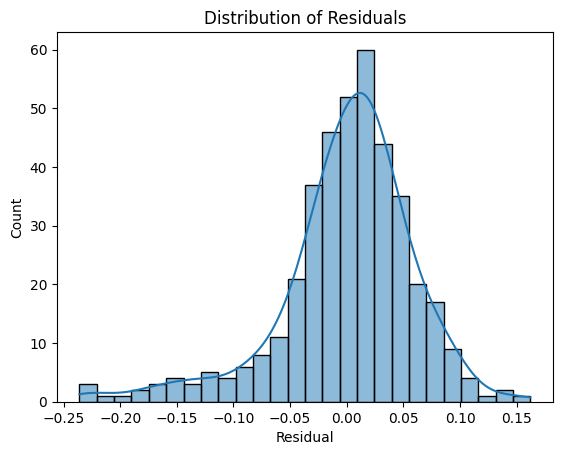

In [ ]:
sns.histplot(residuals, kde=True)

plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.show()

Q-Q Plot

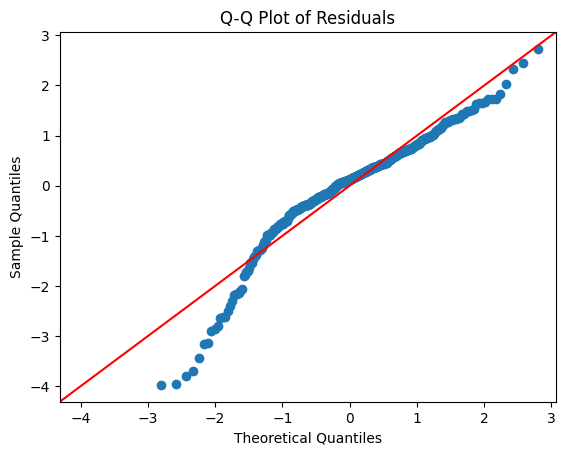

In [ ]:
sm.qqplot(
    residuals,
    line="45",
    fit=True
)

plt.title("Q-Q Plot of Residuals")
plt.show()

The points approximately follow the diagonal line so the residuals are reasonably close to normal.

Shapiro-Wilk Test

In [ ]:
from scipy.stats import shapiro

stat, p = shapiro(residuals)

print("Statistic:", stat)
print("P-value:", p)

Statistic: 0.9291008662710203
P-value: 7.734906730601272e-13


Hypotheses:

H0: Residuals are normally distributed
H1: Residuals are not normally distributed

As  p > 0.05

we don't have sufficient evidence to reject normality.

Model Evaluation

Evaluate predictions on unseen test data.

In [ ]:
X_test_sm = sm.add_constant(X_test)

y_pred = model.predict(X_test_sm)

Actual vs Predicted

In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred.values
})

comparison.head(10)

,Actual,Predicted
0,0.93,0.914575
1,0.84,0.795181
2,0.39,0.572660
3,0.77,0.707370
4,0.74,0.815883
5,0.89,0.862066
6,0.47,0.474597
7,0.57,0.648509
8,0.68,0.823787
9,0.82,0.807415


**MAE**

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 0.04272265427705371


Interpretation:

On average, the model's predicted admission probability differs from the actual value by approximately 0.04272.

Since Chance of Admit ranges from 0 to 1:

0.043 = 4.3 percentage points

So the average prediction error is approximately 4.3 percentage points.

**RMSE**

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 0.06086588041578314


RMSE penalizes large errors more strongly because the errors are squared.

Therefore:

MAE

Treats errors linearly.

RMSE

Penalizes large errors more heavily.

**R² on Test Data**

In [ ]:
r2 = r2_score(y_test, y_pred)

print("R2:", r2)

R2: 0.8188432567829627


Interpretation:

The model explains approximately 81% of the variation in Chance of Admit on the unseen test dataset.

**Adjusted R²**

In [ ]:
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - (
    (1-r2) * (n-1) / (n-p-1)
)

print("Adjusted R2:", adjusted_r2)

Adjusted R2: 0.8050595915381881


Where:

n = number of observations

p = number of predictors

**Complete Evaluation Table**

In [ ]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("Adjusted R2:", adjusted_r2)

MAE: 0.04272265427705371
RMSE: 0.06086588041578314
R2: 0.8188432567829627
Adjusted R2: 0.8050595915381881


In [ ]:
evaluation = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2", "Adjusted R2"],
    "Value": [mae, rmse, r2, adjusted_r2]
})

evaluation

,Metric,Value
0,MAE,0.042723
1,RMSE,0.060866
2,R2,0.818843
3,Adjusted R2,0.805060


**Actual vs Predicted Plot**

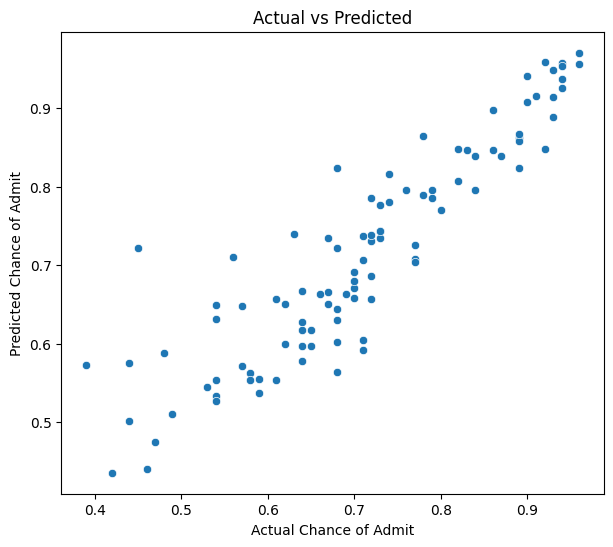

In [ ]:
plt.figure(figsize=(7,6))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

plt.xlabel("Actual Chance of Admit")
plt.ylabel("Predicted Chance of Admit")
plt.title("Actual vs Predicted")

plt.show()

Add a perfect prediction line:

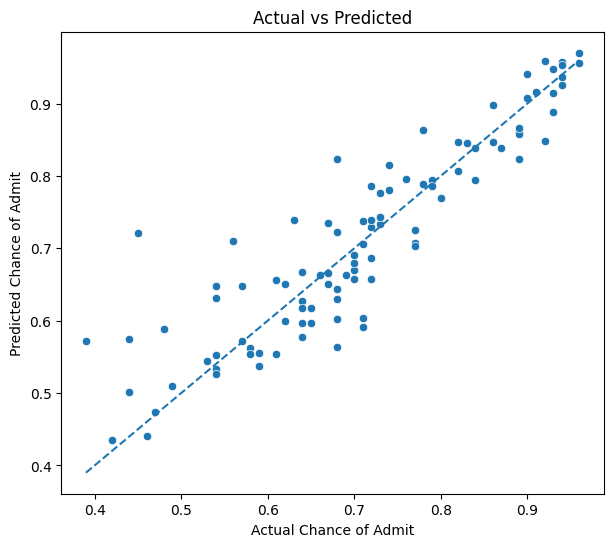

In [ ]:
plt.figure(figsize=(7,6))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Chance of Admit")
plt.ylabel("Predicted Chance of Admit")
plt.title("Actual vs Predicted")

plt.show()

**As Predictions are good, points are close to the diagonal line.**

# **Different Linear Regression Models**

**Model 1 — All Variables**  This is the full model.

In [ ]:
X1 = df.drop("Chance_of_Admit", axis=1)
y = df["Chance_of_Admit"]

X1_train, X1_test, y_train, y_test = train_test_split(
    X1, y,
    test_size=0.20,
    random_state=42
)

X1_train_sm = sm.add_constant(X1_train)

model1 = sm.OLS(y_train, X1_train_sm).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:        Chance_of_Admit   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     257.0
Date:                Fri, 14 Aug 2026   Prob (F-statistic):          3.41e-142
Time:                        05:36:12   Log-Likelihood:                 561.91
No. Observations:                 400   AIC:                            -1108.
Df Residuals:                     392   BIC:                            -1076.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.4214      0.12

Identify Insignificant Variables

In [ ]:
pd.DataFrame({
    "Coefficient": model1.params,
    "P_value": model1.pvalues
})

,Coefficient,P_value
const,-1.421447,9.326216e-27
GRE,0.002434,3.357625e-05
TOEFL,0.002996,1.619658e-03
University_Rating,0.002569,5.414408e-01
SOP,0.001814,7.211636e-01
LOR,0.017238,1.947965e-04
CGPA,0.112527,1.086636e-22
Research,0.024027,1.337508e-03


Look at the p-values.

SOP p-value > 0.05

it means SOP is not statistically significant after accounting for all the other predictors in this particular model.

This does not mean:

SOP has absolutely no relationship with admission.

It means:

Once the other predictors are controlled for, its unique linear contribution is not statistically significant at the chosen significance level.

**Model 2 — Remove Insignificant Variable**

After examining your actual output, you find one or more variables with high p-values.

In [ ]:
X2 = df.drop(
    ["Chance_of_Admit", "SOP"],
    axis=1
)

y = df["Chance_of_Admit"]

X2_train, X2_test, y_train, y_test = train_test_split(
    X2,
    y,
    test_size=0.20,
    random_state=42
)

X2_train_sm = sm.add_constant(X2_train)

model2 = sm.OLS(y_train, X2_train_sm).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:        Chance_of_Admit   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     300.4
Date:                Fri, 14 Aug 2026   Prob (F-statistic):          2.01e-143
Time:                        05:39:01   Log-Likelihood:                 561.85
No. Observations:                 400   AIC:                            -1110.
Df Residuals:                     393   BIC:                            -1082.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.4272      0.12

SOP has high P-value. But don't automatically remove SOP.

First check the p-values from actual model output.

# **Compare Model 1 and Model 2**

In [ ]:
print("Model 1")
print("R2:", model1.rsquared)
print("Adjusted R2:", model1.rsquared_adj)

print("\nModel 2")
print("R2:", model2.rsquared)
print("Adjusted R2:", model2.rsquared_adj)

Model 1
R2: 0.8210671369321554
Adjusted R2: 0.8178719072345153

Model 2
R2: 0.8210089089613841
Adjusted R2: 0.8182762205485808


**Create a function to compare model**

In [ ]:
def evaluate_model(model, X_test, y_test):

    X_test_sm = sm.add_constant(X_test)

    predictions = model.predict(X_test_sm)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    n = len(y_test)
    p = X_test.shape[1]

    adj_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

    return mae, rmse, r2, adj_r2

In [ ]:
mae1, rmse1, r21, adj1 = evaluate_model(
    model1,
    X1_test,
    y_test
)

print(mae1, rmse1, r21, adj1)

0.04272265427705371 0.06086588041578314 0.8188432567829627 0.8050595915381881


# **Model 3 — Standardized Linear Regression**

Standardization puts predictors onto a common scale.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

Then split:

In [ ]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

Statsmodels:

In [ ]:
X_train_s_sm = sm.add_constant(X_train_s)

model3 = sm.OLS(
    y_train_s,
    X_train_s_sm
).fit()

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:        Chance_of_Admit   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     257.0
Date:                Fri, 14 Aug 2026   Prob (F-statistic):          3.41e-142
Time:                        05:44:20   Log-Likelihood:                 561.91
No. Observations:                 400   AIC:                            -1108.
Df Residuals:                     392   BIC:                            -1076.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.7228      0.00

**Prediction for a New Student**

Suppose a student has:

GRE = 325
TOEFL = 110
University Rating = 4
SOP = 4
LOR = 4
CGPA = 9.2
Research = 1

Create :

In [ ]:
new_student = pd.DataFrame({
    "GRE": [325],
    "TOEFL": [110],
    "University_Rating": [4],
    "SOP": [4],
    "LOR": [4],
    "CGPA": [9.2],
    "Research": [1]
})

Add constant:

In [ ]:
new_student_sm = sm.add_constant(new_student, has_constant="add")

**Predict:**

In [ ]:
predicted_chance = model.predict(new_student_sm)

print(predicted_chance)

0    0.845049
dtype: float64


Interpretation:

As we get 0.845049 value. That means the model estimates approximately an 84% admission chance for this applicant based on the patterns learned from the dataset. It is a model-based estimate.

# **Final** Insights:

**Insight 1 — GRE**

GRE generally has a strong positive relationship with Chance of Admit.

Therefore:

Higher GRE performance is associated with better graduate admission prospects.

**Insight 2 — CGPA**

CGPA is also an important predictor.

Therefore:

Strong undergraduate academic performance is associated with higher admission chances.

This is especially useful because CGPA represents sustained academic performance rather than a single examination.

**Insight 3 — TOEFL**

TOEFL generally has a positive relationship with admission chance.

Therefore:

Strong English-language proficiency is associated with better admission prospects.

**Insight 4 — Research Experience**

Applicants with research experience tend to have better admission chances than otherwise similar applicants without research experience, subject to the model's estimated coefficient and significance.

**Insight 5 — University Rating**

University Rating can contribute to admission probability, although its effect should be interpreted after controlling for other variables.

**Insight 6 — GRE/TOEFL/CGPA Correlation**

GRE, TOEFL and CGPA may be strongly correlated.

Therefore:

Jamboree should be careful when interpreting individual coefficients because multicollinearity can make coefficient estimates less stable.

# **Business Recommendations for Jamboree**

Recommendation 1

Jamboree can develop a student admission predictor using:

GRE
TOEFL
CGPA
University Rating
SOP
LOR
Research

Recommendation 2

The website can show students:

Estimated Chance of Admit: 84%

along with a disclaimer that this is a statistical estimate, not a guarantee.

**Recommendation 3**

Instead of only giving a probability, Jamboree could show students their strongest improvement opportunities.

For example:

Current profile:


GRE       315
TOEFL     100
CGPA      8.4
Research  No

To solve this case study I followed
1. Business Understanding
    
2. Load Dataset
        
3. Shape / Info / Describe
        
4. Missing Values
        
5. Duplicate Check
        
6. Unique Values
        
7. Drop Serial No.
        
8. Univariate Analysis
        
9. Bivariate Analysis
        
10. Correlation Analysis
        
11. Train-Test Split
        
12. Statsmodels OLS
        
13. Interpret Coefficients
        
14. Check P-values
        
15. VIF
        
16. Mean Residual
        
17. Residual Plot
        
18. Homoscedasticity
        
19. Normality
        
20. MAE
        
21. RMSE
        
22. R²
        
23. Adjusted R²
        
24. Try Different Models
        
25. Compare Models
        
26. Business Insights
        
27. Recommendations

In [ ]:
!ls

drive  sample_data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!find /content/drive -iname "*Jamboree*"

/content/drive/MyDrive/Colab Notebooks/Jamboree Admission.ipynb
/content/drive/MyDrive/Colab Notebooks/Jamboree Admission.html


In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/Jamboree Admission.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Jamboree Admission.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 21 image(s).
[NbConvertApp] Writing 1442415 bytes to /content/drive/MyDrive/Colab Notebooks/Jamboree Admission.html
